# Deep Learning - Clasificación con BERT
Versión optimizada para Google Colab

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!nvidia-smi

Fri Apr  3 19:41:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             29W /   70W |    5577MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
os.chdir('/content/drive/MyDrive/DeepLearning/proyecto')  # Cambiar a tu ruta en Drive
print(os.getcwd())

/content/drive/MyDrive/DeepLearning/proyecto


In [ ]:
import pandas as pd
import os

Lectura de datos

In [ ]:
data = pd.read_csv('data/raw/respuestas_abril.csv')
data = data.astype({'descripcion': 'string', 'categoria': 'string', 'clasificacion': 'string'})

data

,id,NPS,descripcion,p1,categoria,clasificacion,Unnamed: 6,Unnamed: 7,interesante
0,60882907,10,chirriztun16@gmail.com super genial util sencillo,101,Fácil de usar,Positiva,NaN,NaN,NaN
1,60198234,10,"muy útil, intuitiva y eficaz!",101,Fácil de usar,Positiva,NaN,NaN,NaN
2,60259661,10,está entendible y útil,101,Fácil de usar,Positiva,NaN,NaN,NaN
3,60484383,10,fácil de utilizar,101,Fácil de usar,Positiva,NaN,NaN,NaN
4,60789810,10,muy práctica y fácil,101,Fácil de usar,Positiva,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2757,60910658,10,no me deja ver sinpuedo acceder a una tarjeta ...,vacío,<NA>,Negativa,NaN,NaN,NaN
2758,60911051,10,permitir hacer transferencia a cualquier hora ...,vacío,<NA>,Neutral,NaN,NaN,NaN
2759,60911206,10,excelente app me funcionado de lo mejor,vacío,<NA>,Positiva,NaN,NaN,NaN
2760,60911207,4,las compras deberían reflejarse de inmediato d...,vacío,<NA>,Neutral,NaN,NaN,NaN


In [ ]:
print(f"Registros antes de deduplicar: {data.shape[0]}")
data = data.drop_duplicates(subset=["descripcion"])
print(f"Registros después de deduplicar: {data.shape[0]}")

Registros antes de deduplicar: 2762
Registros después de deduplicar: 1656


In [ ]:
# select columns of interest
columns_of_interest = ["descripcion","categoria","clasificacion"]
data = data[columns_of_interest]
data["label"]=data["clasificacion"]

In [ ]:
# grpupby clasificacion and count
data.groupby('clasificacion').count()

,descripcion,categoria,label
clasificacion,,,
Negativa,487,178,487
Neutral,473,137,473
Positiva,696,491,696


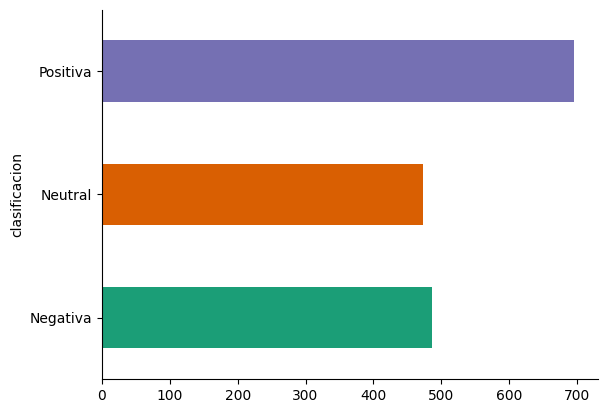

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('clasificacion').size().plot(kind='barh', color=sns.color_palette("Dark2"))
plt.gca().spines[['top',"right"]].set_visible(False)

In [ ]:
data.dtypes

,0
descripcion,string[python]
categoria,string[python]
clasificacion,string[python]
label,string[python]


In [ ]:
data.dtypes

,0
descripcion,string[python]
categoria,string[python]
clasificacion,string[python]
label,string[python]


In [ ]:
# tamaño de muestra
print(f"Tamaño del dataset de muestra es: {data.shape[0]} registros")

Tamaño del dataset de muestra es: 2762 registros


In [ ]:
# @ instalacion de librerias
%pip install transformers torch
%pip install pytorch_pretrained_bert

In [ ]:
# torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torch.nn.functional as F
import torch.optim as optim

from collections import Counter
import argparse
import functools
from torch.utils.data import DataLoader

import json
import numpy as np
from tqdm import tqdm
import shutil

In [ ]:
from transformers import BertTokenizer, BertModel

# BETO: BERT entrenado en español (Wikipedia + corpus español)

In [ ]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(data, test_size=0.1, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.11, random_state=42)

In [ ]:
print(f"Tamaño del dataset de entrenamiento es: {train_data.shape[0]} registros")
print(f"Tamaño del dataset de prueba es: {test_data.shape[0]} registros")
print(f"Tamaño del dataset de validación es: {val_data.shape[0]} registros")

Tamaño del dataset de entrenamiento es: 2211 registros
Tamaño del dataset de prueba es: 277 registros
Tamaño del dataset de validación es: 274 registros


In [ ]:
# Guardar datasets en csv
train_data.to_csv('data/processed/train_data.csv', index=False)
test_data.to_csv('data/processed/test_data.csv', index=False)
val_data.to_csv('data/processed/val_data.csv', index=False)

In [ ]:
class ReviewDataset(Dataset):
    """
    data_path: ruta del archivo .csv que contiene descripcion y categoria
    Args: hiperparametros
    """
    def __init__(self, data_path, args):
        self.data = pd.read_csv(data_path)
        self.tokenizer = BertTokenizer.from_pretrained(
            args.bert_model,
            do_lower_case=True
        ) # funcion que preprocesa el texto y divide en tokens
        self.args = args
        self.n_classes = len(args.labels)
        self.max_seq_length = args.max_seq_length # 512

    def __len__(self):
        return len(self.data)

    def load_text(self, index, key=""):
        inputs = self.tokenizer(self.data.loc[index, key], return_tensors='pt', padding='max_length', truncation=True)
        sentence =inputs.input_ids[0]
        segment = inputs.token_type_ids[0]
        attmask = inputs.attention_mask[0]
        return sentence, segment, attmask

    def __getitem__(self, index):
        sentence, segment, attmask = None, None, None

        # cargar texto y procesar con tokenizer
        sentence, segment, attmask = self.load_text(index, key="descripcion")

        label = torch.zeros(self.n_classes)

        tgt = self.data.loc[index]["label"]
        label[self.args.labels.index(tgt)] = 1
        return sentence, segment, attmask, label

In [ ]:
def get_labels_and_frequencies(path):
    """
     Lee el archivo csv en la ruta dada, extrae las etiquetas de la columna 'categoria' y calcula la frecuencia de cada etiqueta.
     Devuelve una lista de etiquetas únicas y un diccionario con la frecuencia de cada etiqueta."""
    label_freqs = Counter()
    data_labels = list(pd.read_csv(path).label)
    label_freqs.update(data_labels)
    return list(label_freqs.keys()), label_freqs

In [ ]:
def collate_fn(batch,args):
    text_tensor, segment_tensor, attmask_tensor, label_tensor = None, None, None, None

    text_tensor =    torch.stack([row[0] for row in batch])
    segment_tensor = torch.stack([row[1] for row in batch])
    attmask_tensor = torch.stack([row[2] for row in batch])
    tgt_tensor =     torch.stack([row[3] for row in batch])

    return text_tensor, segment_tensor, attmask_tensor, tgt_tensor

In [ ]:
def get_data_loaders(args):
    args.labels, args.label_freqs = get_labels_and_frequencies(
        os.path.join(args.data_path, "train_data.csv")
        )

    args.n_classes = len(args.labels)

    train = ReviewDataset(os.path.join(args.data_path, "train_data.csv"), args)

    args.train_data_len = len(train)

    dev = ReviewDataset(os.path.join(args.data_path, "val_data.csv"), args)

    test_set = ReviewDataset(os.path.join(args.data_path, "test_data.csv"), args)

    collate = functools.partial(collate_fn, args=args)

    train_loader = DataLoader(
        train,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        collate_fn=collate)

    val_loader = DataLoader(
        dev,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        collate_fn=collate)

    test_loader = DataLoader(
        test_set,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        collate_fn=collate)

    return train_loader, val_loader, test_loader

Configuracion del entrenamiento

In [ ]:
import random
# fijar semilla para reproduccion
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
def model_forward(i_epoch, model, args, criterion, batch):
    txt, segment, attmask, tgt = batch
    txt, attmask, segment = txt.to(args.device), attmask.to(args.device), segment.to(args.device)
    out = model(txt, attmask, segment) # la log probabilidad de cada clase para cada ejemplo del batch

    tgt = tgt.to(args.device)
    final_loss = criterion(out, tgt)
    return final_loss, out, tgt

In [ ]:
# para evaluar el modelo
from sklearn.metrics import f1_score, accuracy_score, average_precision_score
from sklearn.metrics import precision_score, recall_score, classification_report

In [ ]:
def model_eval(i_epoch, data, model, args, criterion):
    # no queremos que se propague el gradiente durante la evaluación, por eso usamos torch.no_grad()
    with torch.no_grad():
        losses, preds, tgts = [], [], []
        probs = []
        for batch in data:
            loss, out, tgt = model_forward(i_epoch, model, args, criterion, batch)
            losses.append(loss.item())
            prob = torch.nn.functional.softmax(out, dim=1).cpu().detach().numpy()
            index_max = np.argmax(prob, axis=1)
            pred = np.zeros(prob.shape)
            for i in range(len(index_max)):
                pred[i][index_max[i]] = 1
            preds.append(pred)
            probs.append(prob)
            tgt = tgt.cpu().detach().numpy()
            tgts.append(tgt)

    tgts = np.vstack(tgts)
    preds= np.vstack(preds)
    probs = np.vstack(probs)
    report = classification_report(tgts, preds, output_dict=True)
    metrics = {"loss": np.mean(losses),
              "weighted avg": report["weighted avg"],
               }
    return metrics

In [ ]:
# guarda en cada epoca el estado del modelo actual
def save_checkpoint(state, is_best, checkpoint_path, filename="checkpoint.pt"):
    filename = os.path.join(checkpoint_path, filename)
    torch.save(state, filename)
    if is_best:
        shutil.copyfile(filename, os.path.join(checkpoint_path, "best_model.pt"))

In [ ]:
def train(args, model):
    args.savedir = os.path.join(args.savedir, args.name)
    os.makedirs(args.savedir, exist_ok=True)

    model.to(args.device)

    torch.save(args, os.path.join(args.savedir, "args.pt"))
    start_epoch, global_step, n_no_improve, best_metric = 0, 0, 0, -np.inf

    # cargar el estado del modelo si ya existia previamente
    if os.path.exists(os.path.join(args.savedir, "checkpoint.pt")):
        checkpoint = torch.load(os.path.join(args.savedir, "checkpoint.pt"))

        start_epoch = checkpoint["epoch"] + 1
        global_step = checkpoint.get("global_step", 0)
        n_no_improve = checkpoint["n_no_improve"]
        best_metric = checkpoint["best_metric"]
        model.load_state_dict(checkpoint["state_dict"])
        # configurar el optimizador y la función de pérdida
        optimizer.load_state_dict(checkpoint["optimizer"])
        scheduler.load_state_dict(checkpoint["scheduler"])
        print(f"Modelo cargado desde checkpoint, empezando en epoch {start_epoch} con global step {global_step} y mejor métrica {best_metric}")

    len_train = len(train_loader)
    # caudno termina la epoca la ponemos en modo evaluacion
    for i_epoch in range(start_epoch, args.max_epochs):
        train_losses = []
        model.train()

        for batch in tqdm(train_loader, total=len_train):
            los, _, _ = model_forward(i_epoch, model, args, criterion, batch)
            if args.gradient_accumulation_steps > 1:
                los = los / args.gradient_accumulation_steps
            train_losses.append(los.item())
            # propagar el gradiente
            los.backward()
            global_step += 1

            if global_step % args.gradient_accumulation_steps == 0:
                optimizer.step()
                optimizer.zero_grad()

        model.eval() # desactiva el dropout y otras capas que solo se usan durante el entrenamiento
        # metricas de evaluacion en el set de validacion para monitorear el entrenamiento y ver si el modelo esta mejorando o si se esta sobreajustando
        metrics = model_eval(i_epoch, val_loader, model, args, criterion)
        print(f"Epoch {i_epoch} - Train Loss: {np.mean(train_losses):.4f} ")
        print("Val: ", metrics)


        tunning_metric = (
            # como va el f1 score
            metrics["weighted avg"]["f1-score"]
        )
        # como tiene que reduc
        scheduler.step(tunning_metric)

        is_improvement = tunning_metric > best_metric
        if is_improvement:
            best_metric = tunning_metric
            n_no_improve = 0
        else:
            n_no_improve += 1

        # guardar el estado del modelo actual
        save_checkpoint({
            "epoch": i_epoch,
            "global_step": global_step,
            "n_no_improve": n_no_improve,
            "best_metric": best_metric,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict()
        }, is_improvement, args.savedir)
        # early stopping
        if n_no_improve >= args.patience: # si no mejora durante un numero de epocas consecutivas, se detiene el entrenamiento para evitar sobreajuste
            print(f"No se ha mejorado durante {n_no_improve} epocas consecutivas. Deteniendo entrenamiento.")
            break

    load_checkpoint(model, os.path.join(args.savedir, "best_model.pt"))
    model.eval()
    test_metrics = model_eval(
        np.inf, test_loader, model, args, criterion
    )
    print(f"Tests:", test_metrics)


In [ ]:
def load_checkpoint(model, path):
    best_checkpoint = torch.load(path)
    model.load_state_dict(best_checkpoint["state_dict"])

BERT - BERTO

CLASIFICADOR

In [ ]:
class BertClassfier(nn.Module):
    def __init__(self, args):
        super(BertClassfier, self).__init__()
        self.bert = BertModel.from_pretrained(args.bert_model) # Encoder de texto preentrenado
        self.dropout = nn.Dropout(args.dropout)
        self.classifier = nn.Linear(args.hidden_size, args.n_classes) # cabezal de clasificacion que toma la representacion del [CLS] token y devuelve la log probabilidad de cada clase

    def forward(self, txt, mask, segment):
        """como evaluar
        """
        _, x = self.bert(
            input_ids=txt,
            attention_mask=mask,
            token_type_ids=segment,
            return_dict=False
        )

        x = self.dropout(x) # capa de droput
        return self.classifier(x)

Entrenamiento

In [ ]:
import os
# Verificar disponibilidad de CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

set_seed(1)
args = argparse.Namespace(
    bert_model="dccuchile/bert-base-spanish-wwm-uncased", # modelo preentrenado de BERT en español BASE
    model="bert",
    batch_size=8,
    max_seq_length=512,
    num_workers=2,  # Funciona bien en Colab
    dropout=0.1,
    hidden_size=768, # ESPACIO SEMANTICO
    gradient_accumulation_steps=16,
    max_epochs=10,
    patience=2, # 2 epocas cuando no mejore se detiene el entrenamiento
    lr=1e-4, # tasa de aprendizaje
    lr_factor=0.5,
    warmup=0.1,
    data_path="data/processed", # ruta a los datos
    savedir="models", # ruta a los directorios de guardado
    task="", # tarea a resolver
    name="bert_base_spanish_wwm_uncased", # nombre del modelo
    device=device,
)

Usando dispositivo: cuda


In [ ]:
train_loader, val_loader, test_loader = get_data_loaders(args)

In [ ]:
bert_base = BertClassfier(args)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training o

In [ ]:
# Criterion
freqs = [args.label_freqs[label] for label in args.labels]
# pondera las clases en funcion del numero de ejemplos de cada clase en el set de entrenamiento
label_weights = (torch.FloatTensor(freqs)/args.train_data_len) ** -1
label_weights = label_weights.to(args.device)
criterion = nn.BCEWithLogitsLoss(weight=label_weights)
bert_base.to(args.device)
#optimizador
optimizer = optim.AdamW(bert_base.parameters(), lr=args.lr)
# scheduler para reducir la tasa de aprendizaje si no mejora la métrica de evaluación
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=args.patience, factor=args.lr_factor)

In [ ]:
import shutil
checkpoint_dir = os.path.join("models", args.name)
if os.path.exists(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)
    print(f"Checkpoint eliminado: {checkpoint_dir}")

Checkpoint eliminado: models/bert_base_spanish_wwm_uncased


In [ ]:
# Descomentar para entrenar
train(args, bert_base)

100%|██████████| 277/277 [03:19<00:00,  1.39it/s]


Epoch 0 - Train Loss: 0.1147 
Val:  {'loss': np.float64(1.2867662225450789), 'weighted avg': {'precision': 0.8475717856692663, 'recall': 0.7591240875912408, 'f1-score': 0.7391651493318179, 'support': 274.0}}


100%|██████████| 277/277 [03:17<00:00,  1.41it/s]


Epoch 1 - Train Loss: 0.0540 
Val:  {'loss': np.float64(0.8104103863239288), 'weighted avg': {'precision': 0.9020843904914321, 'recall': 0.9014598540145985, 'f1-score': 0.9011420149095173, 'support': 274.0}}


100%|██████████| 277/277 [03:16<00:00,  1.41it/s]


...

Epoch 3 - Train Loss: 0.0264 
Val:  {'loss': np.float64(0.7303679932441031), 'weighted avg': {'precision': 0.9271267418712674, 'recall': 0.927007299270073, 'f1-score': 0.9270371898109124, 'support': 274.0}}


100%|██████████| 277/277 [03:16<00:00,  1.41it/s]


Epoch 4 - Train Loss: 0.0217 
Val:  {'loss': np.float64(0.600319662477289), 'weighted avg': {'precision': 0.9264150484032551, 'recall': 0.9197080291970803, 'f1-score': 0.9213382320848682, 'support': 274.0}}


100%|██████████| 277/277 [03:16<00:00,  1.41it/s]


Epoch 5 - Train Loss: 0.0165 
Val:  {'loss': np.float64(0.7400775466646466), 'weighted avg': {'precision': 0.9215854018335793, 'recall': 0.9233576642335767, 'f1-score': 0.9217830825105218, 'support': 274.0}}
No se ha mejorado durante 2 epocas consecutivas. Deteniendo entrenamiento.
Tests: {'loss': np.float64(0.7794861192149776), 'weighted avg': {'precision': 0.9225591740581056, 'recall': 0.9205776173285198, 'f1-score': 0.9194986084876664, 'support': 277.0}}


Evaluar predicciones unitarias

In [ ]:
def model_predict(model, text, args):
    with torch.no_grad():
        tokenizer = BertTokenizer.from_pretrained(args.bert_model, do_lower_case=True)
        inputs = tokenizer(text, return_tensors="pt", padding="max_length", truncation=True)
        txt = inputs.input_ids
        segment = inputs.token_type_ids
        attmask = inputs.attention_mask
        txt, attmask, segment = txt.to(args.device), attmask.to(args.device), segment.to(args.device)

        out = model(txt, attmask, segment)
        prob = torch.nn.functional.softmax(out[0], dim=0)
        index_max = prob.argmax(dim=0).item()
        pred = args.labels[index_max]

        return pred, prob

In [ ]:
# Ejemplo de uso:
# text = "la app es muy facil de usar"
# model_predict(bert_base, text, args)

In [ ]:
text = "la app es muy facil de usar y me facilita mucho hacer mis pagos y transferencias. asi como consultar mis estados de cuenta. siempre la recomiendo. gracias por el excelente servicio"
model_predict(bert_base, text, args)

('Positiva', tensor([6.7077e-05, 9.9988e-01, 5.2849e-05], device='cuda:0'))

In [ ]:
text = "gshhwy"
model_predict(bert_base, text, args)

('Neutral', tensor([7.4783e-04, 8.6095e-03, 9.9064e-01], device='cuda:0'))

In [ ]:
text = "transferir desde un apartado."
model_predict(bert_base, text, args)

('Neutral', tensor([0.0011, 0.0018, 0.9971], device='cuda:0'))

In [ ]:
text = "Tengo problemas y no tengo como solucionarlo"
model_predict(bert_base, text, args)

('Negativa', tensor([0.9658, 0.0206, 0.0136], device='cuda:0'))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def eval_detallado(model, loader, args, criterion):
    model.eval()
    with torch.no_grad():
        losses, preds_idx, tgts_idx = [], [], []
        for batch in loader:
            loss, out, tgt = model_forward(0, model, args, criterion, batch)
            losses.append(loss.item())
            prob = torch.nn.functional.softmax(out, dim=1).cpu().detach().numpy()
            preds_idx.extend(np.argmax(prob, axis=1).tolist())
            tgts_idx.extend(np.argmax(tgt.cpu().detach().numpy(), axis=1).tolist())

    # Reporte por clase
    print(classification_report(tgts_idx, preds_idx, target_names=args.labels, zero_division=0))

    # Matriz de confusión
    cm = confusion_matrix(tgts_idx, preds_idx)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=args.labels, yticklabels=args.labels)
    plt.ylabel("Real")
    plt.xlabel("Predicho")
    plt.title("Matriz de confusión")
    plt.tight_layout()
    plt.show()

              precision    recall  f1-score   support

    Negativa       0.81      0.91      0.86        47
    Positiva       0.95      0.98      0.96       168
     Neutral       0.92      0.77      0.84        62

    accuracy                           0.92       277
   macro avg       0.90      0.89      0.89       277
weighted avg       0.92      0.92      0.92       277



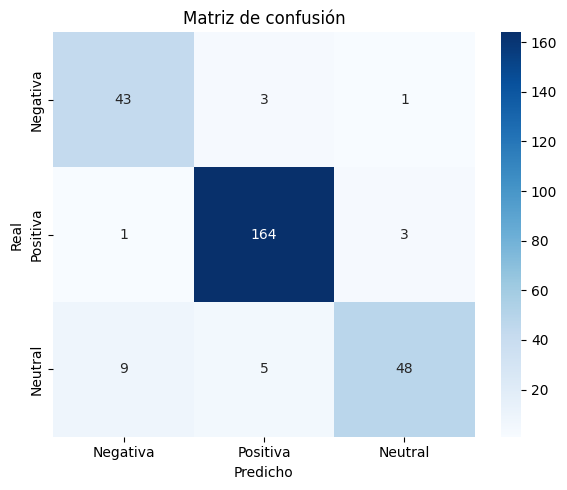

In [ ]:
eval_detallado(bert_base, test_loader, args, criterion)